In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('bmh')

In [197]:
class DistanceCellModel():

    def __init__(self, M = 10, s_M = 25, alpha = 1.4, m = 20, r_max = 30, N_dc = 12500, dc_res = 4, time_w = 0.1):
        self.M = M          # Number of GC modules
        self.s_M = s_M      # Minimum grid scale (for geometric progression)
        self.alpha = alpha  # Common factor (for geometric progression)
        self.m = m          # Number of equally distributes spatial phases
        self.r_max = r_max  # Maximum GC firing rate (Hz)
        self.N_dc = N_dc    # Number of distance cells
        self.dc_res = dc_res       # Distance cell spatial resolution (cm)
        self.poiss_time_w = time_w # Time window in Poisson process (secs)

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()
        self.dc_positions = self._create_distance_cells()
        self.W_dcs = self._compute_weight_matrix()  
        self.W_pos_readout = self.dc_positions / self.dc_positions.max()  # Increases linearly with displacement along axis
        self.W_neg_readout = self.W_pos_readout.copy()[::-1]              # Decreases linearly (to encode opposite direction)

    def _create_scales(self):
        ''' Creates M scales according to geometric progression '''
        scales = []
        for i in np.arange(self.M, 0, -1):
            new_scale = round(self.s_M * (self.alpha ** (self.M-i)),2)
            scales.append(new_scale)
        return scales

    def _create_phases(self):
        ''' Creates m equally spaced phases from 0 to 2π in radians'''
        return np.linspace(0, 2 * np.pi, self.m, endpoint=False)
    
    def _create_distance_cells(self):
        ''' Creates N_dc distance cell according to spatial resolution '''
        return np.arange(0, self.N_dc * self.dc_res, self.dc_res)
    
    def _compute_weight_matrix(self):
        ''' For each distance cell a, compute rate of cell j at scale i (i.e., r_ij) '''
        all_weights = []
        for curr_distance in self.dc_positions:
            distance_weights = []
            for s_i in self.scales:
                for p_ij in self.phases:
                    r_ij = self.gc_rate(curr_distance, s_i, p_ij)
                    distance_weights.append(r_ij)
            all_weights.append(distance_weights)
        return np.array(all_weights)

    def gc_rate(self, a, s_i, p_ij):
        ''' Calculates GC firing rate based on cosine tuned rate function '''
        num_bracket = (a - (s_i * (p_ij / (2 * np.pi)))) / s_i
        return self.r_max * (1 + np.cos(num_bracket * 2 * np.pi)) / 2
    
    def GC_spikes(self, a):
        ''' Given current position a, calculate GC spikes for all GCs in our network '''
        gc_spikes = []
        for s_i in self.scales:
            for p_ij in self.phases:
                r_ij = self.gc_rate(a, s_i, p_ij)
                spikes_ij = np.random.poisson(lam = self.poiss_time_w * r_ij)
                #print(f"GC at phase {p_ij} with rate {np.round(r_ij)}: spikes: {spikes_ij}")
                gc_spikes.append(spikes_ij)
        return np.array(gc_spikes)
    
    def emax_N_normalize(self, x, epsilon=0.01):
        ''' Applies E%-max algorithm and normalzation steps '''
        # E%-max algorithm: silence all values below (1-epsilon) of the maximum value
        threshold = x.max() * (1 - epsilon)
        dc_activations = np.where(x >= threshold, x, 0.0)

        # Normalize so total activity is constant across simulations
        total = dc_activations.sum()
        if total > 0:
            dc_activations = dc_activations / total
        return dc_activations

    def forward(self, a, b):
        ''' Given current position a and target position b, apply forward pass by 
            1) calculating GC spikes
            2) multiplying it with the network weights
            3) applying E%-max algorithm & normalization step
        '''

        # 1. Calculate spikes for all GCs in our network start & goal positions
        start_gc_activations = self.GC_spikes(a)
        goal_gc_activations = self.GC_spikes(b)

        #2. Compute forward passes
        start_dc_activations = self.emax_N_normalize(self.W_dcs @ start_gc_activations)
        goal_dc_activations = self.emax_N_normalize(self.W_dcs @ goal_gc_activations)

        # 5. Read-out cells
        read_out_one = self.W_neg_readout @ start_dc_activations + self.W_pos_readout @ goal_dc_activations 
        read_out_two = self.W_pos_readout @ start_dc_activations + self.W_neg_readout @ goal_dc_activations
        read_out_diff = read_out_one - read_out_two
        decoded_position = read_out_diff * (self.dc_positions.max()/2) # Convert back to cm - need division to account for four weights
        return decoded_position
    
  
dc_model = DistanceCellModel()
print(dc_model.forward(a=250, b=258))
print(dc_model.forward(a=250, b=248))
# Edge cases
print(dc_model.forward(a=250, b=0))
print(dc_model.forward(a=250, b=50000))
print(dc_model.forward(a=250, b=500))

10.008384142675629
-1.9904438052701137
-247.98577350759507
49747.99999999999
252.00000000000236


In [ ]:
dc_model.forward(a=250, b=2)

-252.00000000000236

Simulation

(array([ 65.,  79.,  84., 106., 137., 131., 124., 124.,  85.,  65.]),
 array([8.00000000e+00, 4.97939922e+03, 9.95079844e+03, 1.49221977e+04,
        1.98935969e+04, 2.48649961e+04, 2.98363953e+04, 3.48077945e+04,
        3.97791938e+04, 4.47505930e+04, 4.97219922e+04]),
 <BarContainer object of 10 artists>)

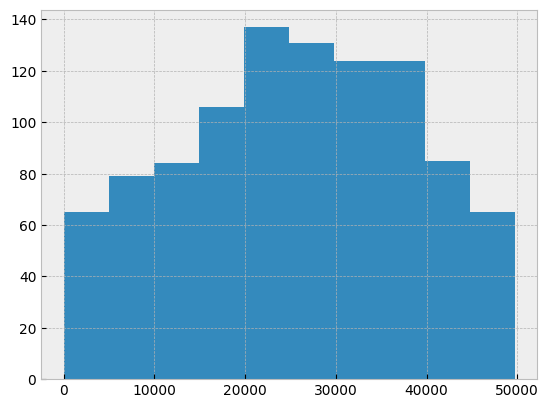

In [193]:
plt.hist(b_hats)

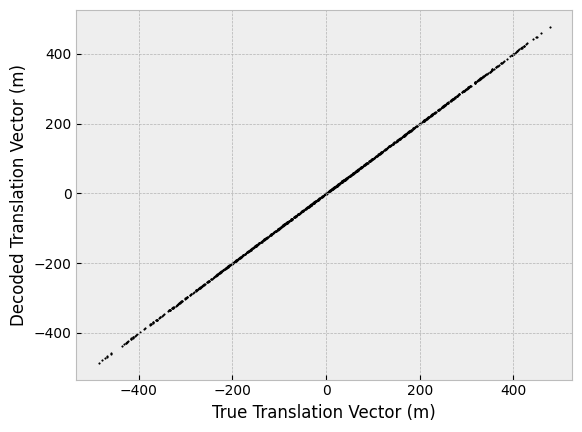

In [201]:
N=1000    # Num of simulations
arena_width = 50000 # cm
dc_model = DistanceCellModel()

a_s = np.random.rand(N) * arena_width
b_s = np.random.rand(N) * arena_width
b_hats = []
for i in range(N):
    b_hats.append(dc_model.forward(a=a_s[i], b=b_s[i]))
b_hats = np.array(b_hats)

plt.scatter((b_s-a_s) / 100, b_hats / 100, color='black', s=1)
plt.xlabel('True Translation Vector (m)')
plt.ylabel('Decoded Translation Vector (m)')
plt.show()